# Decode In/Out from stim2 period

See if you can decode whether stim2 was in vs out during the stim2 period

Can try decoding using different groups of neurons and seeing how well they do

Do neurons know during stim2 whether stim2 is a match or mismatch? 
- At what point during stim2 do they know? Maybe can train on correct trials end of probe
    - For correct trials, answer should be yes
    - For incorrect trials, answer might be no; maybe “RT” is later?


Do this now for exc and inh neurons

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *

2025-05-27 15:38:13.439287: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-27 15:38:13.448768: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-27 15:38:13.459057: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-27 15:38:13.462335: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-27 15:38:13.470637: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# import SVM
from sklearn import svm
from sklearn.metrics import confusion_matrix

## Get bad models

In [3]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [4]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [5]:
# get list of models with performance btwn 60-80%

bad_models = []
for model_name in model_dirs:
    # get model directory
    model_dir = os.path.join(all_models_dir, model_name)
    
    _, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    if np.mean(trial_perfs) > 0.6 and np.mean(trial_perfs) < 0.8:
        bad_models.append(model_name)
        print(f'{model_name} has performance {np.mean(trial_perfs)}, bad model # {len(bad_models)}')

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645 has performance 0.679, bad model # 1
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926 has performance 0.781, bad model # 2
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648 has performance 0.683, bad model # 3
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449 has performance 0.644, bad model # 4
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139 has performance 0.654, bad model # 5
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959 has performance 0.782, bad model # 6
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_080217 has performance 0.763, bad model # 7
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191643 has performance 0.648, bad model # 8
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906 has performance 0.743, bad model # 9
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_004449 has performance 0.757, bad model # 10
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoi

## Loop thru bad models and do decoding

### now repeat for many models

In [6]:
import concurrent.futures
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import svm

def decode_model(model_name, cell_subset):
    print(f'Starting model: {model_name}')
    
    # Load data (your existing code)
    _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                           load_LFP=False, load_spikes=False, load_rates=True)
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num)
    times_ms, _, _ = ld.get_times_dict('ds', condn_phrase, condn_num, model_name)


    # get untuned idxs
    tuning = sn.calc_stim1_tuning_spikes(model_name, condn_phrase, condn_num)
    untuned_ind = np.where(np.isnan(tuning))[0]
    n_cells = len(tuning)
    
    # get exc and inh labels
    exc_ind, inh_ind = ld.get_celltype_label(model_name)

    if cell_subset == 'exc':
        cell_inds = exc_ind
    elif cell_subset == 'inh':
        cell_inds = inh_ind
    elif cell_subset == 'untuned':
        cell_inds = untuned_ind
    elif cell_subset == 'tuned':
        cell_inds = np.setdiff1d(np.arange(n_cells), untuned_ind)
    elif cell_subset == 'all':
        cell_inds = np.arange(n_cells)
    else:
        print('Invalid cell subset. Please choose from "exc", "inh", "untuned", or "all". You chose: ', cell_subset)
        return None

    rates_data = rates_data[:, cell_inds, :]  # Select the subset of cells


    n_iter = 100
    n_cv = 5
    n_time_splits = 5

    # train decoder
    acc_corr = np.zeros((n_iter, n_time_splits))
    acc_corr_null = np.zeros_like(acc_corr)
    acc_incorr = np.zeros((n_iter, n_time_splits))
    acc_incorr_null = np.zeros_like(acc_incorr)

    correct_idx = np.where(trial_perfs == 1)[0]
    incorrect_idx = np.where(trial_perfs == 0)[0]

    corr_labels = trial_labels[correct_idx] # get labels for correct trials
    n_corr_in = np.sum(corr_labels[:, 0] == corr_labels[:, 1])
    n_corr_out = len(corr_labels) - n_corr_in
    n_corr_sample = int(np.min([n_corr_in, n_corr_out]))  # balanced

    # balance incorrect trials too
    incorr_labels = trial_labels[incorrect_idx] # get labels for incorrect trials
    n_incorr_in = np.sum(incorr_labels[:, 0] == incorr_labels[:, 1])
    n_incorr_out = len(incorr_labels) - n_incorr_in
    n_incorr_sample = int(np.min([n_incorr_in, n_incorr_out]))  # balanced

    # time period segments
    stim2_windows = np.linspace(times_ms['stim2_on'], times_ms['stim2_off'], n_time_splits+1, dtype=int)

    for i in range(n_iter):

        # Get pools of correct trials for each class
        in_corr_pool = correct_idx[trial_labels[correct_idx, 0] == 1]
        out_corr_pool = correct_idx[trial_labels[correct_idx, 0] == -1]
        in_incorr_pool = incorrect_idx[trial_labels[incorrect_idx, 0] == 1]
        out_incorr_pool = incorrect_idx[trial_labels[incorrect_idx, 0] == -1]

        # Balanced sampling
        corr_sample_in = np.random.choice(in_corr_pool, n_corr_sample, replace=True)
        corr_sample_out = np.random.choice(out_corr_pool, n_corr_sample, replace=True)
        corr_sample = np.concatenate((corr_sample_in, corr_sample_out))
        incorr_sample_in = np.random.choice(in_incorr_pool, n_incorr_sample, replace=True)
        incorr_sample_out = np.random.choice(out_incorr_pool, n_incorr_sample, replace=True)
        incorr_sample = np.concatenate((incorr_sample_in, incorr_sample_out))
        if n_incorr_sample == 0 or n_corr_sample == 0:
            return None  

        n_splits = 2
        n_test = int(np.floor(len(corr_sample) / n_splits))
        n_train = len(corr_sample) - n_test

        for j in range(n_cv):
            sample_indices = np.arange(len(corr_sample))
            test_indices = np.random.choice(sample_indices, n_test, replace=False)
            train_indices = np.setdiff1d(sample_indices, test_indices)

            test_idx = corr_sample[test_indices]
            train_idx = corr_sample[train_indices]

            # get labels for test and train trials
            train_labels = trial_labels[train_idx,0]
            test_labels = trial_labels[test_idx,0]

            # get data for test and train trials  
            train_data = np.mean(rates_data[stim2_windows[-2]:stim2_windows[-1],:,:], axis=0) # train on last time window of stim2
            train_data = train_data[:, train_idx].T # train on first half delay of one set
            # test_data_delay2 = np.mean(rates_data[delay_times_half2,:,:], axis=0) # test on second half delay 
            # test_data_stim2 = np.mean(rates_data[stim2_times,:,:], axis=0) # test on stim2 period

            # fit SVM to training data
            clf = svm.SVC(kernel='linear', C=1.0)
            clf.fit(train_data, train_labels)
            clf_null = svm.SVC(kernel='linear', C=1.0) # null w shuffled labels
            train_labels_null = np.random.permutation(train_labels) # shuffle labels
            clf_null.fit(train_data, train_labels_null)

            # predict on test data
            for i_time_split in range(n_time_splits):
                this_time_range = np.arange(stim2_windows[i_time_split], stim2_windows[i_time_split+1])

                test_data_corr = np.mean(rates_data[this_time_range,:,:], axis=0) # test on stim2 period of other set of corrects
                test_data_corr = test_data_corr[:, test_idx].T # test on stim2 period of other set of corrects
                pred_labels_corr = clf.predict(test_data_corr)
                pred_labels_corr_null = clf_null.predict(test_data_corr)
                acc_corr[i, i_time_split] += np.mean(pred_labels_corr == test_labels)
                acc_corr_null[i, i_time_split] += np.mean(pred_labels_corr_null == test_labels)

                # predict on test data, from incorrect trials
                test_data_incorr = np.mean(rates_data[this_time_range,:,:], axis=0) # test on stim2 period of incorrects
                test_data_incorr = test_data_incorr[:, incorr_sample].T # test on stim2 period of incorrects
                pred_labels_incorr = clf.predict(test_data_incorr)
                pred_labels_incorr_null = clf_null.predict(test_data_incorr)
                acc_incorr[i, i_time_split] += np.mean(pred_labels_incorr == trial_labels[incorr_sample,0])
                acc_incorr_null[i, i_time_split] += np.mean(pred_labels_incorr_null == trial_labels[incorr_sample,0])
        
        # divide by n_cv
        acc_corr[i, :] /= n_cv
        acc_corr_null[i, :] /= n_cv
        acc_incorr[i, :] /= n_cv
        acc_incorr_null[i, :] /= n_cv
    # store results
    return {
        'model_name': model_name,
        'acc_corr': acc_corr,
        'acc_incorr': acc_incorr,
        'acc_corr_null': acc_corr_null,
        'acc_incorr_null': acc_incorr_null
    }

#### exc

In [7]:
cell_subsets = ["exc" for i in range(len(bad_models))]

# Use ProcessPoolExecutor to parallelize across models
with concurrent.futures.ProcessPoolExecutor() as executor:
    results = list(executor.map(decode_model, bad_models,cell_subsets))

results = [r for r in results if r is not None]  # Filter out None results

# Combine and save
decoding_results_df = pd.DataFrame(results)
decoding_results_df.to_pickle(f'results_data/decode_inout_exc_results_bad_models_{condn_phrase}{condn_num}.pkl')

Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959

Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_080217Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_004449Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191643Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191340Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_002808Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_134839

Starting model: Task_xor_N_200_Ta

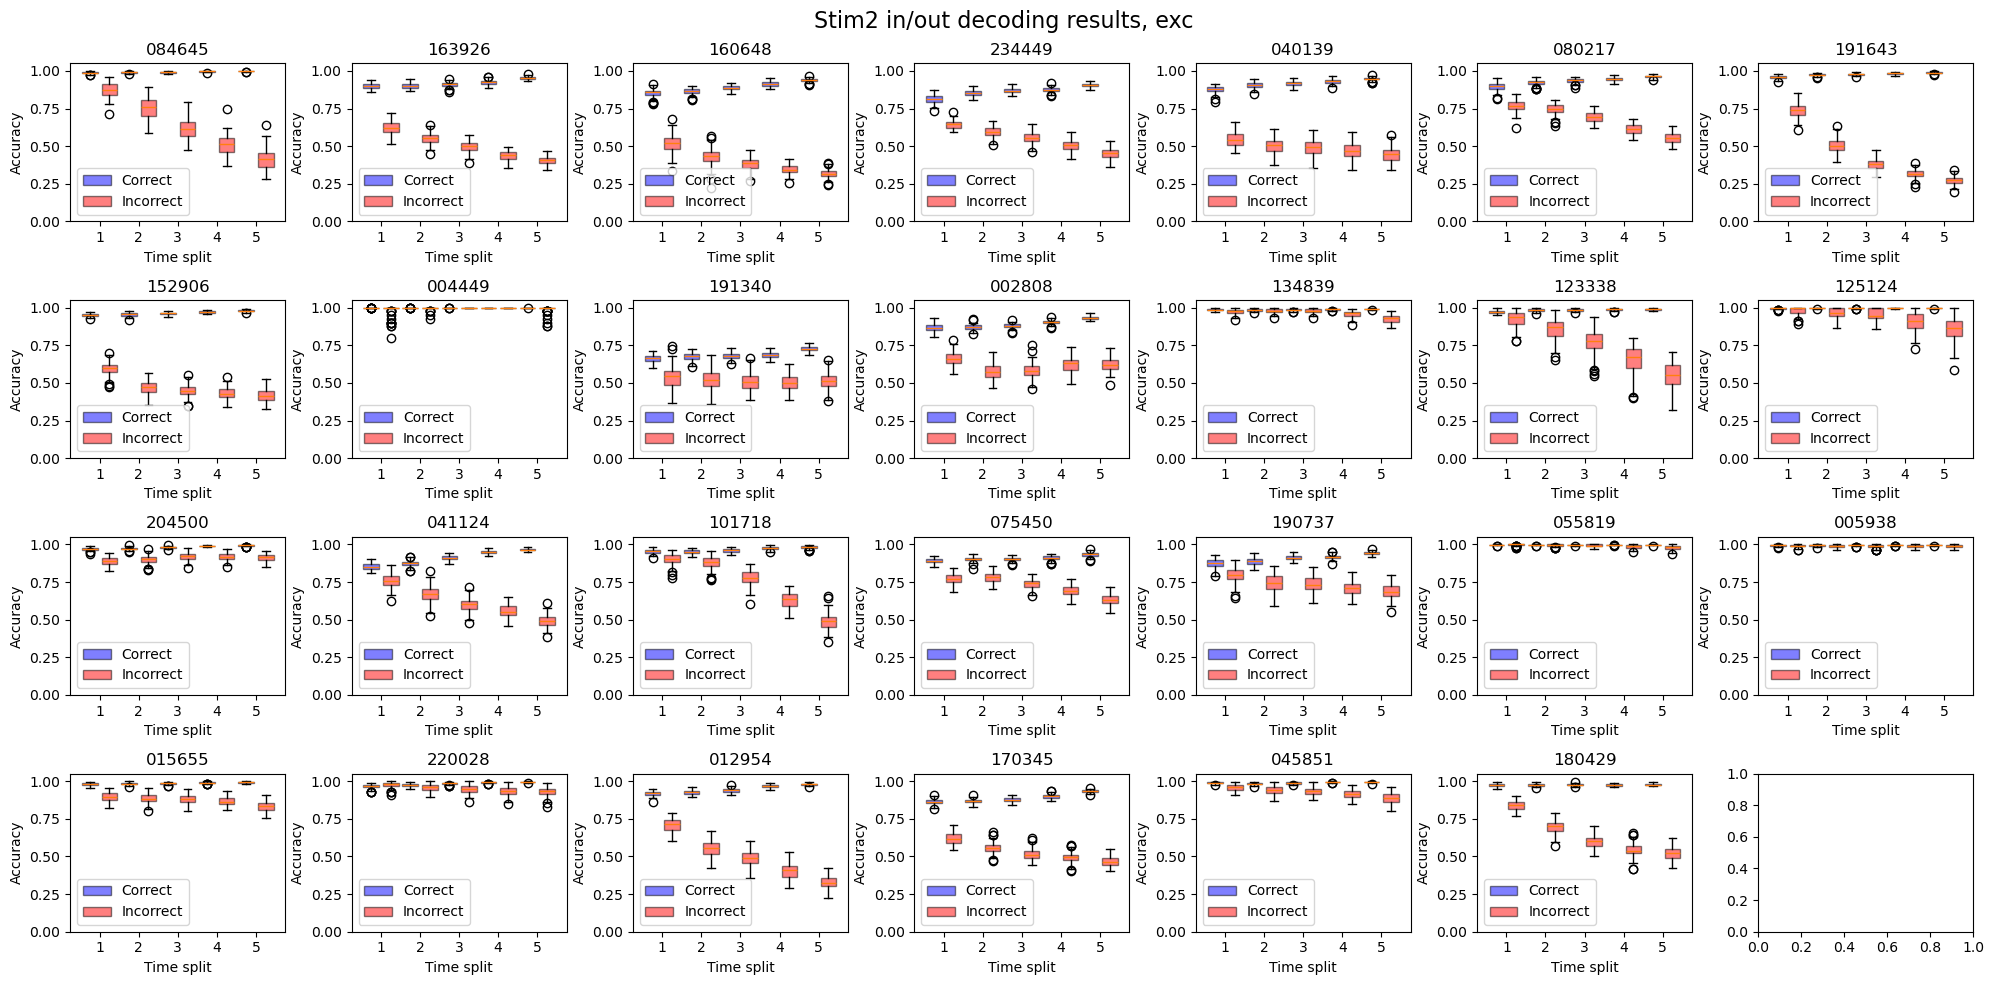

In [8]:
# plot them as boxplots

fig, axs = plt.subplots(4, 7, figsize=(20, 10))
fig.suptitle(f'Stim2 in/out decoding results, exc', fontsize=16)
axs = axs.flatten()

for i_model, model_data in decoding_results_df.iterrows():
    model_name = model_data['model_name'][-6:]
    acc_corr = model_data['acc_corr']
    acc_incorr = model_data['acc_incorr']
    acc_corr_null = model_data['acc_corr_null']
    acc_incorr_null = model_data['acc_incorr_null']
    n_time_splits = acc_corr.shape[1]

    for i in range(n_time_splits):
        bp = axs[i_model].boxplot([acc_corr[:, i]], positions=[i-.25], widths=0.4, patch_artist=True)
        for k, box in enumerate(bp['boxes']):
            box.set_facecolor('blue')  # Set the face color of the box
            box.set_edgecolor('black')  # Optionally set edge color
            box.set_alpha(0.5)  # Set transparency (optional)
        bp = axs[i_model].boxplot([acc_incorr[:, i]], positions=[i+0.25], widths=0.4, patch_artist=True)
        for k, box in enumerate(bp['boxes']):
            box.set_facecolor('red')  # Set the face color of the box
            box.set_edgecolor('black')  # Optionally set edge color
            box.set_alpha(0.5)  # Set transparency (optional)
        # axs[i_model].boxplot([acc_corr[:, i], acc_incorr[:, i]], positions=[i-.25, i+0.25], widths=0.4)
        axs[i_model].set_xticks(np.arange(0, n_time_splits, 1))
        axs[i_model].set_xticklabels(np.arange(1, n_time_splits+1, 1))
        axs[i_model].set_xlabel('Time split')
        axs[i_model].set_ylabel('Accuracy')
        axs[i_model].set_title(model_name)
        axs[i_model].legend(['Correct', 'Incorrect'])
        axs[i_model].set_ylim(0, 1.05)

        # plot correct as blue and incorrect as red
        


plt.tight_layout()
plt.show()
    

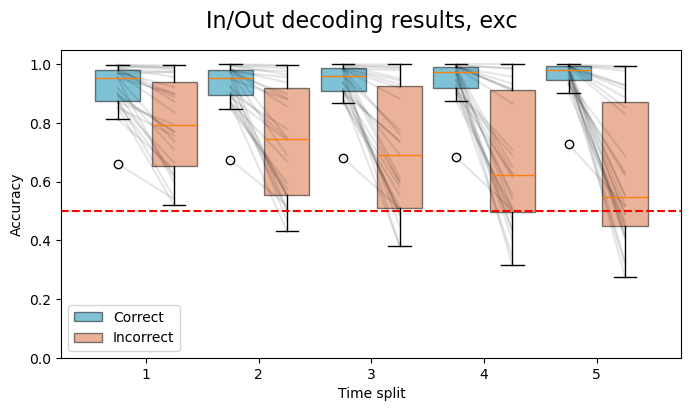

In [9]:
# now take mean and aggregate across models and do boxplot

corr_means = np.zeros((len(decoding_results_df), n_time_splits))
incorr_means = np.zeros_like(corr_means)
corr_null_means = np.zeros_like(corr_means)
incorr_null_means = np.zeros_like(corr_means)


for i_model, model_data in decoding_results_df.iterrows():
    corr_means[i_model] = np.mean(model_data['acc_corr'], axis=0)
    incorr_means[i_model] = np.mean(model_data['acc_incorr'], axis=0)
    corr_null_means[i_model] = np.mean(model_data['acc_corr_null'], axis=0)
    incorr_null_means[i_model] = np.mean(model_data['acc_incorr_null'], axis=0)

n_time_splits = acc_corr.shape[1]

fig, axs = plt.subplots(1, 1, figsize=(8, 4))
fig.suptitle(f'In/Out decoding results, exc', fontsize=16)
colors = ['#0085AD','#D76735','#222F5B','#B12A0C']
for i in range(n_time_splits):
    bp = axs.boxplot([corr_means[:, i], incorr_means[:, i]], 
                positions=[i-.25, i+0.25], widths=0.4, patch_artist=True)
    axs.plot([i-.25, i+0.25], [corr_means[:,i], incorr_means[:,i]], color='black', alpha=0.1)
    
    for k, box in enumerate(bp['boxes']):
        box.set_facecolor(colors[k])
        box.set_edgecolor('black')  # Optionally set edge color
        box.set_alpha(0.5)
axs.set_xticks(np.arange(0, n_time_splits, 1))
axs.set_xticklabels(np.arange(1, n_time_splits+1, 1))
axs.set_xlabel('Time split')
axs.set_ylabel('Accuracy')
axs.legend(['Correct', 'Incorrect'])
axs.set_ylim(0, 1.05)
axs.axhline(y=0.5, color='r', linestyle='--')

plt.show()

#### inh

In [10]:
cell_subsets = ["inh" for i in range(len(bad_models))]

# Use ProcessPoolExecutor to parallelize across models
with concurrent.futures.ProcessPoolExecutor() as executor:
    results = list(executor.map(decode_model, bad_models,cell_subsets))

results = [r for r in results if r is not None]  # Filter out None results

# Combine and save
decoding_results_df = pd.DataFrame(results)
decoding_results_df.to_pickle(f'results_data/decode_inout_inh_results_bad_models_{condn_phrase}{condn_num}.pkl')

Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_080217



Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191643Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_002808
Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_004449Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_134839Starting model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191340
Starting model: Task_xor_N_200_

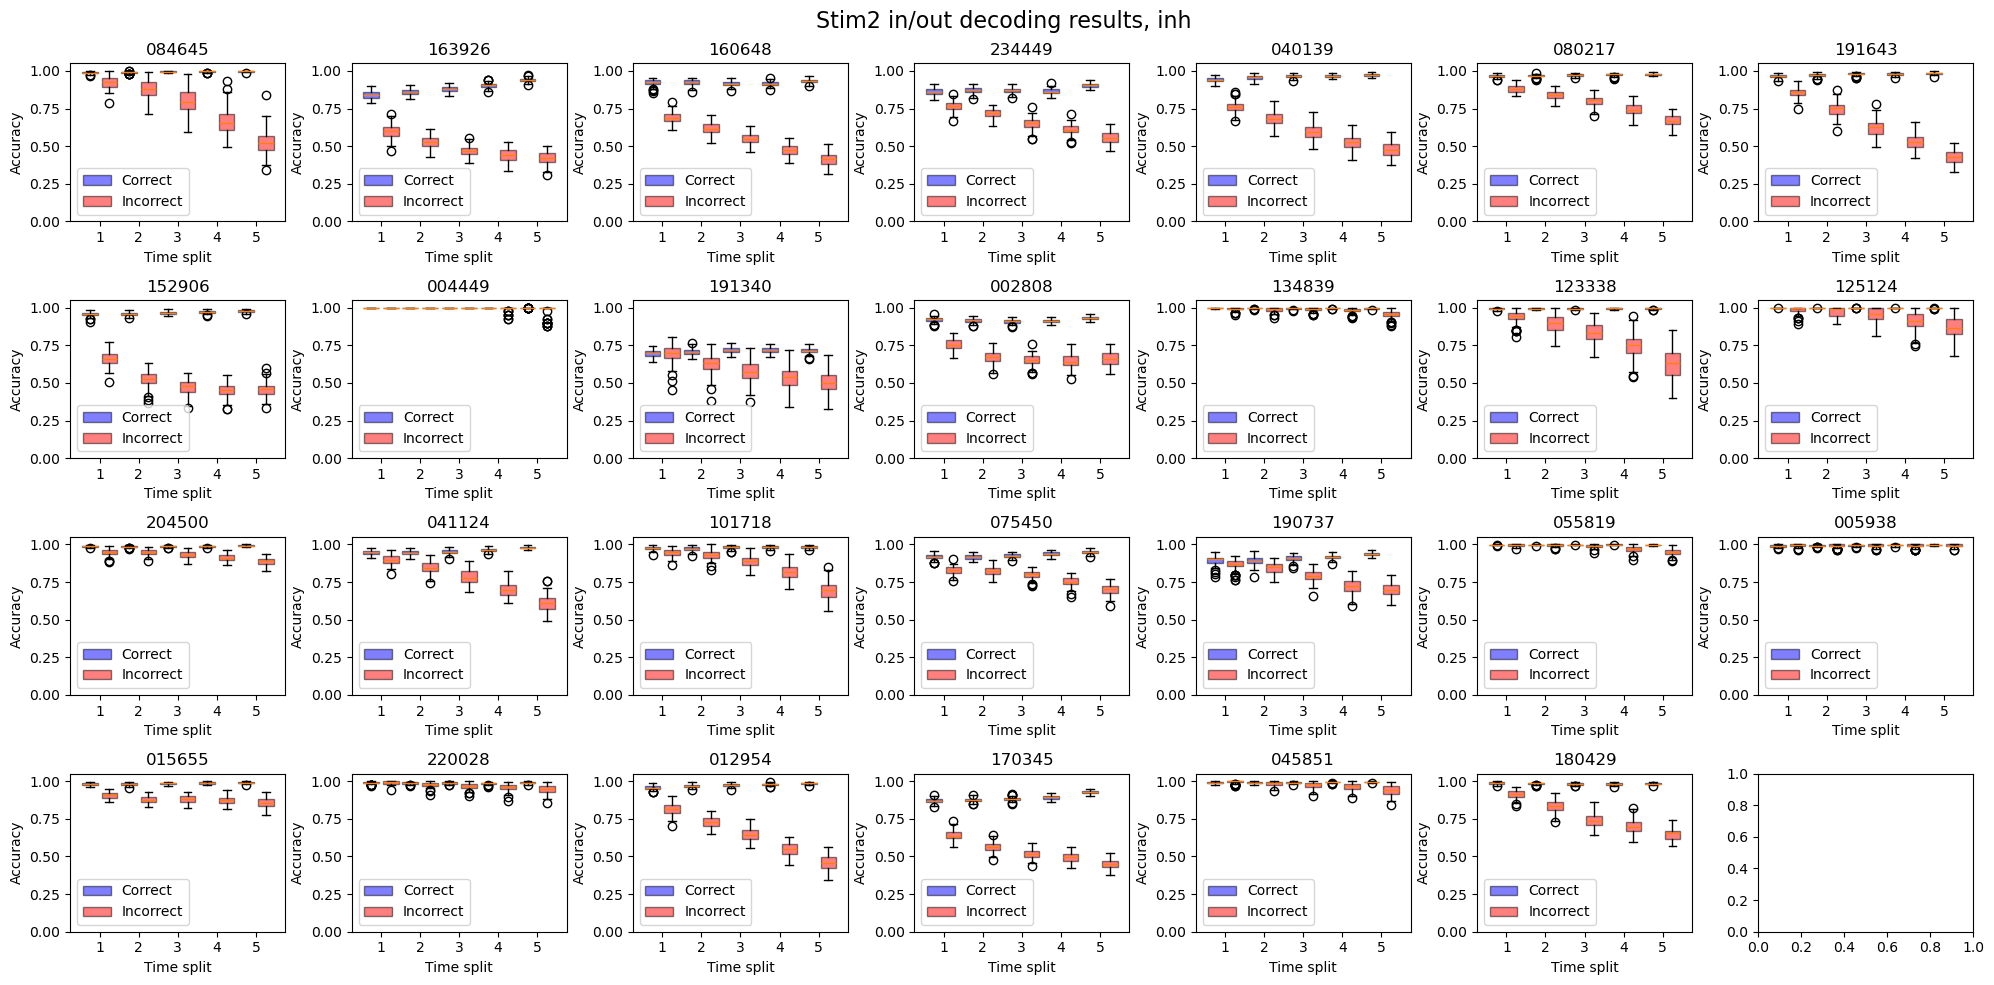

In [11]:
# plot them as boxplots

fig, axs = plt.subplots(4, 7, figsize=(20, 10))
fig.suptitle(f'Stim2 in/out decoding results, inh', fontsize=16)
axs = axs.flatten()

for i_model, model_data in decoding_results_df.iterrows():
    model_name = model_data['model_name'][-6:]
    acc_corr = model_data['acc_corr']
    acc_incorr = model_data['acc_incorr']
    acc_corr_null = model_data['acc_corr_null']
    acc_incorr_null = model_data['acc_incorr_null']
    n_time_splits = acc_corr.shape[1]

    for i in range(n_time_splits):
        bp = axs[i_model].boxplot([acc_corr[:, i]], positions=[i-.25], widths=0.4, patch_artist=True)
        for k, box in enumerate(bp['boxes']):
            box.set_facecolor('blue')  # Set the face color of the box
            box.set_edgecolor('black')  # Optionally set edge color
            box.set_alpha(0.5)  # Set transparency (optional)
        bp = axs[i_model].boxplot([acc_incorr[:, i]], positions=[i+0.25], widths=0.4, patch_artist=True)
        for k, box in enumerate(bp['boxes']):
            box.set_facecolor('red')  # Set the face color of the box
            box.set_edgecolor('black')  # Optionally set edge color
            box.set_alpha(0.5)  # Set transparency (optional)
        # axs[i_model].boxplot([acc_corr[:, i], acc_incorr[:, i]], positions=[i-.25, i+0.25], widths=0.4)
        axs[i_model].set_xticks(np.arange(0, n_time_splits, 1))
        axs[i_model].set_xticklabels(np.arange(1, n_time_splits+1, 1))
        axs[i_model].set_xlabel('Time split')
        axs[i_model].set_ylabel('Accuracy')
        axs[i_model].set_title(model_name)
        axs[i_model].legend(['Correct', 'Incorrect'])
        axs[i_model].set_ylim(0, 1.05)

        # plot correct as blue and incorrect as red
        


plt.tight_layout()
plt.show()
    

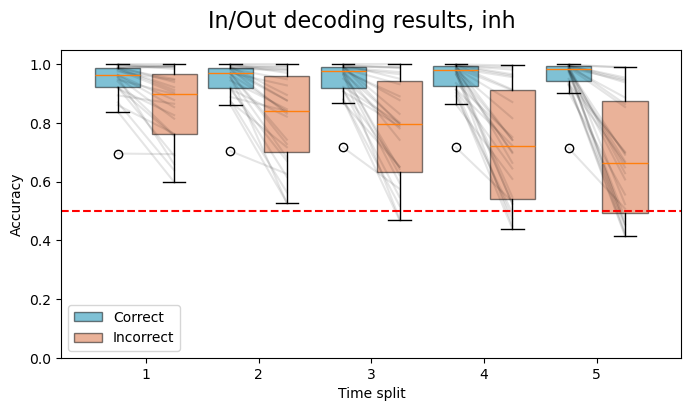

In [12]:
# now take mean and aggregate across models and do boxplot

corr_means = np.zeros((len(decoding_results_df), n_time_splits))
incorr_means = np.zeros_like(corr_means)
corr_null_means = np.zeros_like(corr_means)
incorr_null_means = np.zeros_like(corr_means)


for i_model, model_data in decoding_results_df.iterrows():
    corr_means[i_model] = np.mean(model_data['acc_corr'], axis=0)
    incorr_means[i_model] = np.mean(model_data['acc_incorr'], axis=0)
    corr_null_means[i_model] = np.mean(model_data['acc_corr_null'], axis=0)
    incorr_null_means[i_model] = np.mean(model_data['acc_incorr_null'], axis=0)

n_time_splits = acc_corr.shape[1]

fig, axs = plt.subplots(1, 1, figsize=(8, 4))
fig.suptitle(f'In/Out decoding results, inh', fontsize=16)
colors = ['#0085AD','#D76735','#222F5B','#B12A0C']
for i in range(n_time_splits):
    bp = axs.boxplot([corr_means[:, i], incorr_means[:, i]], 
                positions=[i-.25, i+0.25], widths=0.4, patch_artist=True)
    axs.plot([i-.25, i+0.25], [corr_means[:,i], incorr_means[:,i]], color='black', alpha=0.1)
    
    for k, box in enumerate(bp['boxes']):
        box.set_facecolor(colors[k])
        box.set_edgecolor('black')  # Optionally set edge color
        box.set_alpha(0.5)
axs.set_xticks(np.arange(0, n_time_splits, 1))
axs.set_xticklabels(np.arange(1, n_time_splits+1, 1))
axs.set_xlabel('Time split')
axs.set_ylabel('Accuracy')
axs.legend(['Correct', 'Incorrect'])
axs.set_ylim(0, 1.05)
axs.axhline(y=0.5, color='r', linestyle='--')

plt.show()